<div style="
  background: linear-gradient(145deg, #1a0b08, #2d1310);
  border: 4px solid transparent;
  border-radius: 14px;
  padding: 18px 22px;
  margin: 12px 0;
  font-size: 26px;
  font-weight: 600;
  color: #fff8f6;
  box-shadow: 0 6px 14px rgba(0,0,0,0.3);
  background-clip: padding-box;
  position: relative;
">
  <div style="
    position: absolute;
    inset: 0;
    padding: 4px;
    border-radius: 14px;
    background: linear-gradient(90deg, #ff7b00, #ff0054, #9d0208);
    -webkit-mask: 
      linear-gradient(#fff 0 0) content-box, 
      linear-gradient(#fff 0 0);
    -webkit-mask-composite: xor;
    mask-composite: exclude;
    pointer-events: none;
  "></div>
  
  <b>03 - Facial Expression Recognition with Keras</b>
  <br>
  <span style="color:#ffb5a7; font-size: 18px;">CNN to Recognize Human Facial Expressions in Real Time with OpenCV and Flask</span>
</div>

<div align="center">
  <a href="https://colab.research.google.com/github/mohd-faizy/03P_Facial_Expression_Recoginition/blob/master/01_Facial_Expression_Recoginition_with_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
</div>

---

# Table of Contents

1. [Environment Setup & Dataset Acquisition](#1-environment-setup--dataset-acquisition)
   - 1.1 [Download Project Dataset](#11-download-project-dataset)
   - 1.2 [Dataset Acquisition & Extraction](#12-dataset-acquisition-and-extraction)
   - 1.3 [Verify Dataset Structure](#13-verify-dataset-structure)
   - 1.4 [Install Project Dependencies](#14-install-project-dependencies)
2. [Task 1: Import Libraries & Hardware Setup](#2-task-1-import-libraries--hardware-setup)
   - 2.1 [Import Core Libraries & TensorFlow Backend](#21-import-core-libraries--tensorflow-backend)
3. [Task 2: Exploratory Data Analysis & Sample Visualization](#3-task-2-exploratory-data-analysis--sample-visualization)
   - 3.1 [Dataset Overview & Class Frequency Table](#31-dataset-overview--class-frequency-table)
   - 3.2 [Train vs. Test Distribution & Class Imbalance](#32-train-vs-test-distribution--class-imbalance)
   - 3.3 [Multi-Sample Facial Emotion Gallery](#33-multi-sample-facial-emotion-gallery)
   - 3.4 [Composite Average Face per Emotion (Eigen-Faces)](#34-composite-average-face-per-emotion-eigen-faces)
   - 3.5 [Pixel Intensity Distribution & Contrast Analysis](#35-pixel-intensity-distribution--contrast-analysis)
4. [Task 3: Generate Training & Validation Batches](#4-task-3-generate-training--validation-batches)
   - 4.1 [Batch Size & Hyperparameter Guidelines](#41-batch-size--hyperparameter-guidelines)
   - 4.2 [Real-Time Data Augmentation with ImageDataGenerator](#42-real-time-data-augmentation-with-imagedatagenerator)
   - 4.3 [Categorical One-Hot Encoding & Validation Settings](#43-categorical-one-hot-encoding--validation-settings)
5. [Task 4: Design Deep CNN Architecture](#5-task-4-design-deep-cnn-architecture)
   - 5.1 [Architecture Overview & Literature Reference](#51-architecture-overview--literature-reference)
   - 5.2 [Construct & Compile Deep CNN with Keras](#52-construct--compile-deep-cnn-with-keras)
6. [Task 5: Train and Evaluate Model](#6-task-5-train-and-evaluate-model)
   - 6.1 [Model Checkpointing & Learning Rate Scheduling](#61-model-checkpointing--learning-rate-scheduling)
   - 6.2 [Execute Model Training with Live Loss Monitoring](#62-execute-model-training-with-live-loss-monitoring)
   - 6.3 [Keras Training Callbacks & Reference](#63-keras-training-callbacks--reference)
7. [Task 6: Serialize Model Architecture to JSON](#7-task-6-serialize-model-architecture-to-json)
   - 7.1 [Export Model Architecture to JSON String](#71-export-model-architecture-to-json-string)
8. [Task 7: Real-Time Inference Flask Application](#8-task-7-real-time-inference-flask-application)
   - 8.1 [Camera Video Stream Processing (src/camera.py)](#81-camera-video-stream-processing-srccamerapy)
   - 8.2 [Facial Expression Inference Engine (src/model.py)](#82-facial-expression-inference-engine-srcmodelpy)
   - 8.3 [HTML Web Interface Template (templates/index.html)](#83-html-web-interface-template-templatesindexhtml)
   - 8.4 [Deploy & Run Real-Time Flask Server (main.py)](#84-deploy--run-real-time-flask-server-mainpy)
9. [Project Summary & Key Takeaways](#9-project-summary--key-takeaways)

---


<a id="1-environment-setup--dataset-acquisition"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">1. Environment Setup & Dataset Acquisition</span>

<a id="11-download-project-dataset"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.1 Download Project Dataset</span>

The project dataset containing facial expression training/testing images and the custom helper module (`utils`) is available via the link below:

- **Download Link**: [Project Dataset Folder (Dropbox)](https://www.dropbox.com/s/rzy7401554q57gg/Project.zip)

<a id="12-dataset-acquisition-and-extraction"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.2 Dataset Acquisition & Extraction</span>

Fetch the project dataset archive directly from Dropbox, unzip it, and set up `train/`, `test/`, and `utils/` in the project root directory for seamless local or Colab training.

In [1]:
# 1. Download Project.zip from Dropbox directly into the environment
!curl -L -o Project.zip "https://www.dropbox.com/scl/fi/zpamlummigq0a74aqcmu8/Project.zip?rlkey=h9hn0qr10pxulmtrh4frv2ryw&dl=1"

# 2. Unzip the project archive (contains train/, test/, and utils/)
!unzip -uq Project.zip

# 3. Copy extracted folders (train, test, utils) into the project directory
!cp -rn Project/train . 2>/dev/null || cp -r Project/train .
!cp -rn Project/test . 2>/dev/null || cp -r Project/test .
!cp -rn Project/utils . 2>/dev/null || cp -r Project/utils .

# 4. Clean up temporary archive and extracted root folder
!rm -rf Project.zip Project
print("✅ Dataset and utils successfully downloaded and extracted!")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0     36      0 --:--:-- --:--:-- --:--:--    36
100   475    0   475    0     0    413      0 --:--:--  0:00:01 --:--:--   413
100  112M  100  112M    0     0  40.4M      0  0:00:02  0:00:02 --:--:--  105M
✅ Dataset and utils successfully downloaded and extracted!


<a id="13-verify-dataset-structure"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">1.3 Verify Dataset Structure</span>

Confirm that the training and validation dataset splits are present and display the number of classes available for training.

In [2]:
# Verify working directory and extracted dataset splits
import os

print(f"Working Directory: {os.getcwd()}")
for split in ['train', 'test']:
    if os.path.exists(split):
        classes = sorted(os.listdir(split))
        print(f"✅ Found '{split}/' directory with {len(classes)} classes: {classes}")
    else:
        print(f"❌ '{split}/' directory missing!")

if os.path.exists('utils'):
    print("✅ Found 'utils/' helper module.")
else:
    print("❌ 'utils/' module missing!")

Working Directory: /content
✅ Found 'train/' directory with 7 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
✅ Found 'test/' directory with 7 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
✅ Found 'utils/' helper module.


> [!TIP]
> **Alternative: Python Package Import via `sys.path`**  
> If you prefer not to change the working directory, you can dynamically append your module directory to `sys.path`:
> ```python
> import sys
> sys.path.insert(0, '/the/folder/path/name-package/')
> ```
> Ensure an `__init__.py` exists in the target directory so Python recognizes it as an importable package.

<a id="2-task-1-import-libraries--hardware-setup"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">2. Task 1: Import Libraries & Hardware Setup</span>

<a id="21-import-core-libraries--tensorflow-backend"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">2.1 Import Core Libraries & TensorFlow Backend</span>

In [3]:
!pip install livelossplot  -q # for google colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.0/639.0 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 138.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 13.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.17.1 which is incompatible.


In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import utils

%matplotlib inline

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, Flatten, Conv2D
from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model

from IPython.display import SVG, Image
from livelossplot import PlotLossesKerasTF

In [6]:
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<a id="3-task-2-exploratory-data-analysis--sample-visualization"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">3. Task 2: Exploratory Data Analysis & Sample Visualization</span>

<a id="31-dataset-overview--class-frequency-table"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.1 Dataset Overview & Class Frequency Table</span>

- Quantifying the distribution of facial expression samples across both `train/` and `test/` splits.
- Compiling class totals, individual split percentages, and overall representation ratios.

In [7]:
# Compile dataset class frequencies across train and test splits into a summary table
import os
import pandas as pd

emotions = sorted(os.listdir('train/'))
train_counts = [len(os.listdir(os.path.join('train', e))) for e in emotions]
test_counts = [len(os.listdir(os.path.join('test', e))) for e in emotions]
total_train = sum(train_counts)
total_test = sum(test_counts)

df_summary = pd.DataFrame({
    'Emotion': [e.capitalize() for e in emotions],
    'Train Count': train_counts,
    'Train Share (%)': [round((c / total_train) * 100, 2) for c in train_counts],
    'Test Count': test_counts,
    'Test Share (%)': [round((c / total_test) * 100, 2) for c in test_counts],
    'Total Images': [tr + te for tr, te in zip(train_counts, test_counts)]
})

print(f"Total Training Samples:   {total_train:,}")
print(f"Total Validation Samples: {total_test:,}")
print(f"Grand Total Dataset:      {total_train + total_test:,}")
df_summary


Total Training Samples:   28,709
Total Validation Samples: 7,178
Grand Total Dataset:      35,887


,Emotion,Train Count,Train Share (%),Test Count,Test Share (%),Total Images
0,Angry,3995,13.92,958,13.35,4953
1,Disgust,436,1.52,111,1.55,547
2,Fear,4097,14.27,1024,14.27,5121
3,Happy,7215,25.13,1774,24.71,8989
4,Neutral,4965,17.29,1233,17.18,6198
5,Sad,4830,16.82,1247,17.37,6077
6,Surprise,3171,11.05,831,11.58,4002


<a id="32-train-vs-test-distribution--class-imbalance"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.2 Train vs. Test Distribution & Class Imbalance</span>

- Side-by-side grouped frequency plot comparing category counts in `train/` and `test/` splits.
- Donut chart illustrating training class proportion, highlighting the significant class imbalance for `disgust` (~1.5%) relative to `happy` (~25.1%).

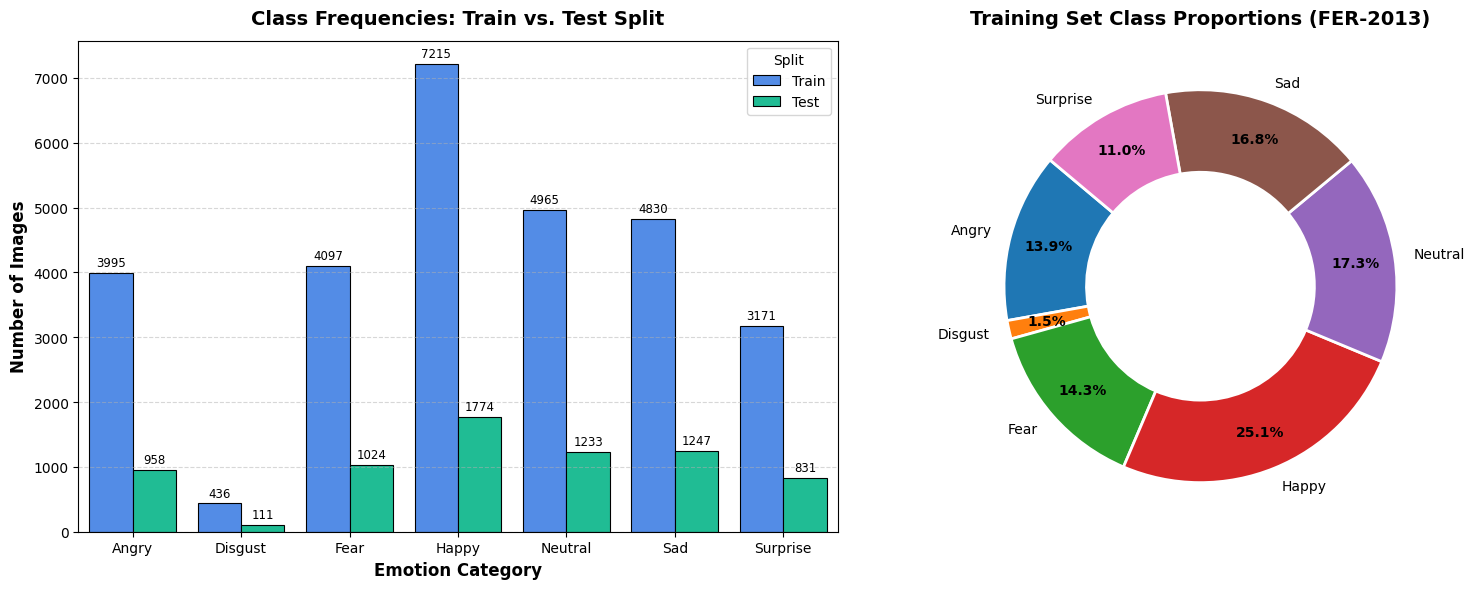

In [8]:
# Visualizing class frequency distributions with side-by-side grouped bar plot and donut chart
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Grouped Bar Chart (Train vs. Test)
df_plot = pd.DataFrame({
    'Emotion': [e.capitalize() for e in emotions] * 2,
    'Count': train_counts + test_counts,
    'Split': ['Train'] * len(emotions) + ['Test'] * len(emotions)
})

sns.barplot(x='Emotion', y='Count', hue='Split', data=df_plot, palette={'Train': '#3a86ff', 'Test': '#06d6a0'}, ax=ax1, edgecolor='black', linewidth=0.8)
ax1.set_title('Class Frequencies: Train vs. Test Split', fontsize=14, fontweight='bold', pad=12)
ax1.set_xlabel('Emotion Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h + 60),
                     ha='center', va='bottom', fontsize=8.5, rotation=0)

# 2. Donut Chart (Train Proportions)
colors = sns.color_palette('tab10', len(emotions))
wedges, texts, autotexts = ax2.pie(
    train_counts,
    labels=[e.capitalize() for e in emotions],
    autopct='%1.1f%%',
    pctdistance=0.8,
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax2.set_title('Training Set Class Proportions (FER-2013)', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

<a id="33-multi-sample-facial-emotion-gallery"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.3 Multi-Sample Facial Emotion Gallery</span>

- Visualizing multiple distinct 48x48 grayscale samples per emotion category to observe intra-class facial variation, expressions, head poses, and lighting.

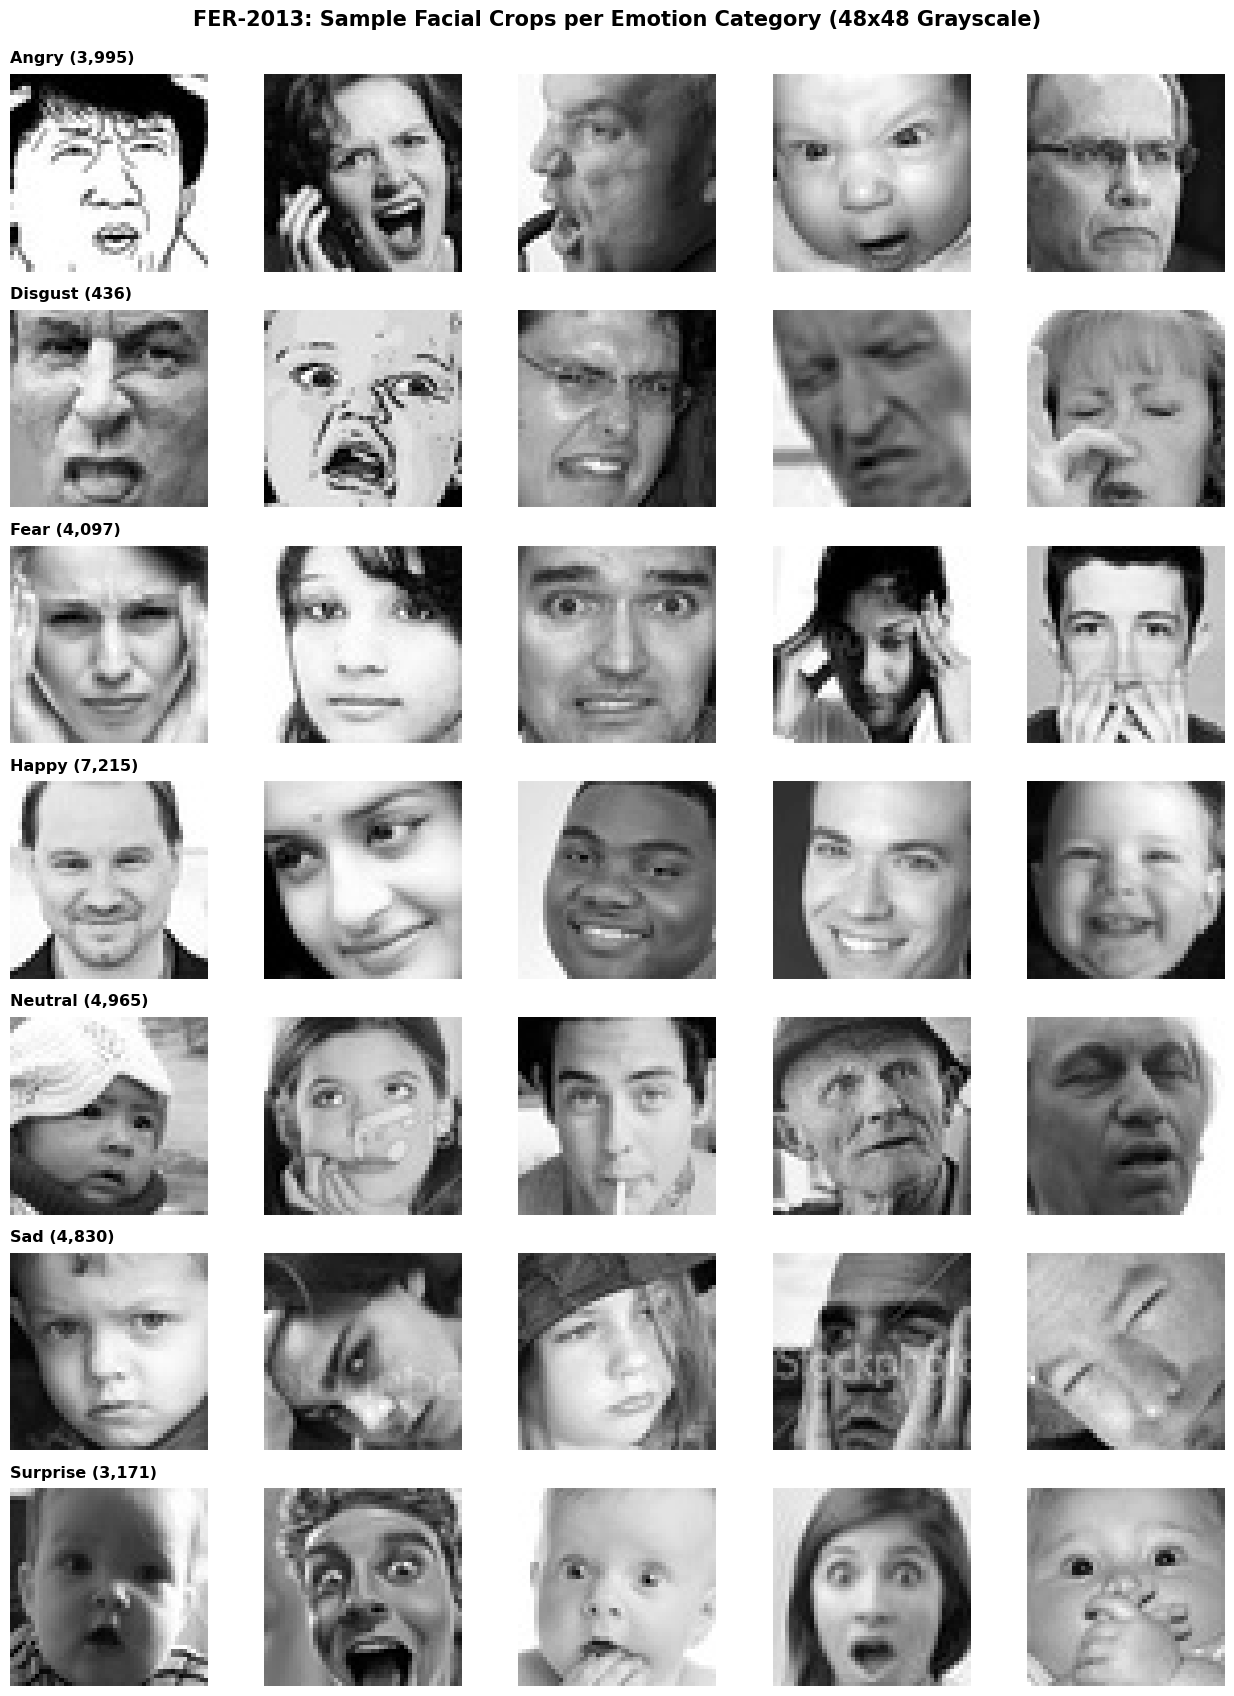

In [9]:
# Displaying a 7x5 gallery of diverse facial crops per emotion category
import cv2
import random

random.seed(42)
samples_per_class = 5
fig, axes = plt.subplots(len(emotions), samples_per_class, figsize=(13, 17))

for row_idx, emotion in enumerate(emotions):
    folder_path = os.path.join('train', emotion)
    sample_files = random.sample(os.listdir(folder_path), samples_per_class)
    for col_idx, img_name in enumerate(sample_files):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        ax = axes[row_idx, col_idx]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(f"{emotion.capitalize()} ({len(os.listdir(folder_path)):,})",
                         fontsize=11.5, fontweight='bold', loc='left', pad=8)

plt.suptitle("FER-2013: Sample Facial Crops per Emotion Category (48x48 Grayscale)", fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

<a id="34-composite-average-face-per-emotion-eigen-faces"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.4 Composite Average Face per Emotion (Eigen-Faces)</span>

- A classic computer vision technique: compute the mean pixel matrix across all images in each class:
  $$\bar{I}_{c}(x, y) = \frac{1}{N_c} \sum_{i=1}^{N_c} I_{c, i}(x, y)$$
- Computing the composite average face reveals the generalized spatial morphology of each expression (e.g., upward mouth curve in `Happy`, open mouth in `Surprise`, furrowed brow in `Angry`).

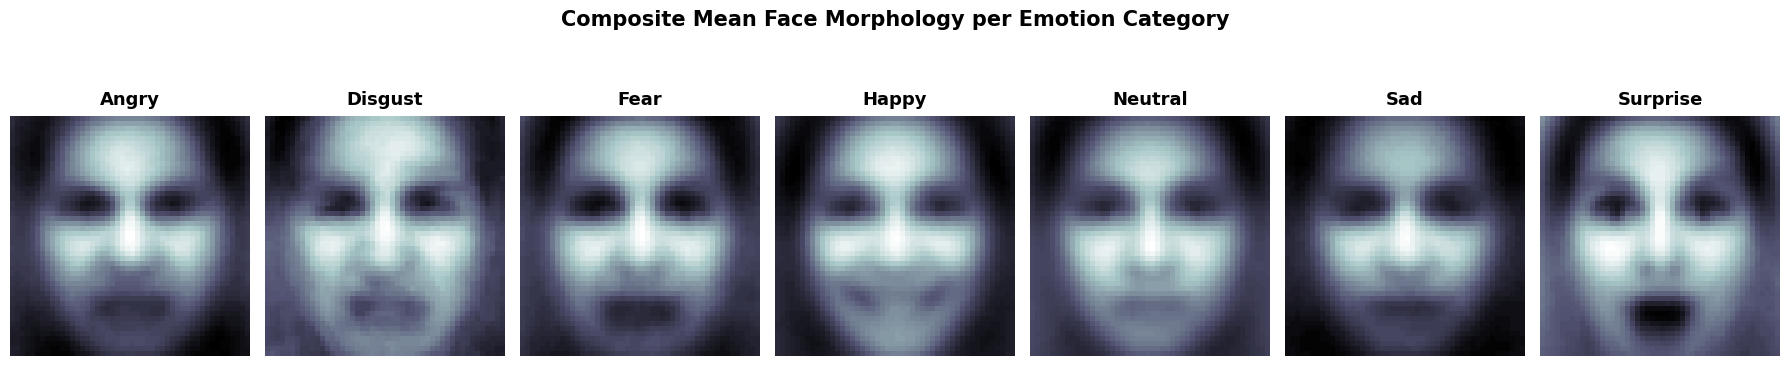

In [10]:
# Computing and visualizing the composite 'average face' per emotion category
import numpy as np

fig, axes = plt.subplots(1, len(emotions), figsize=(18, 3.8))

for idx, emotion in enumerate(emotions):
    folder_path = os.path.join('train', emotion)
    files = os.listdir(folder_path)
    accumulated = np.zeros((48, 48), dtype=np.float32)
    for fname in files:
        img = cv2.imread(os.path.join(folder_path, fname), cv2.IMREAD_GRAYSCALE)
        accumulated += img
    
    mean_face = (accumulated / len(files)).astype(np.uint8)
    ax = axes[idx]
    ax.imshow(mean_face, cmap='bone')
    ax.set_title(f"{emotion.capitalize()}", fontsize=13, fontweight='bold', pad=8)
    ax.axis('off')

plt.suptitle("Composite Mean Face Morphology per Emotion Category", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

<a id="35-pixel-intensity-distribution--contrast-analysis"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">3.5 Pixel Intensity Distribution & Contrast Analysis</span>

- Checking pixel value spread (0 to 255) and average crop illumination across emotion classes to confirm lighting consistency and verify that classification is driven by facial features rather than exposure bias.

/tmp/ipykernel_1456/3472429499.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Emotion', y='Mean Brightness', data=df_brightness, palette='coolwarm', ax=ax2, width=0.6)


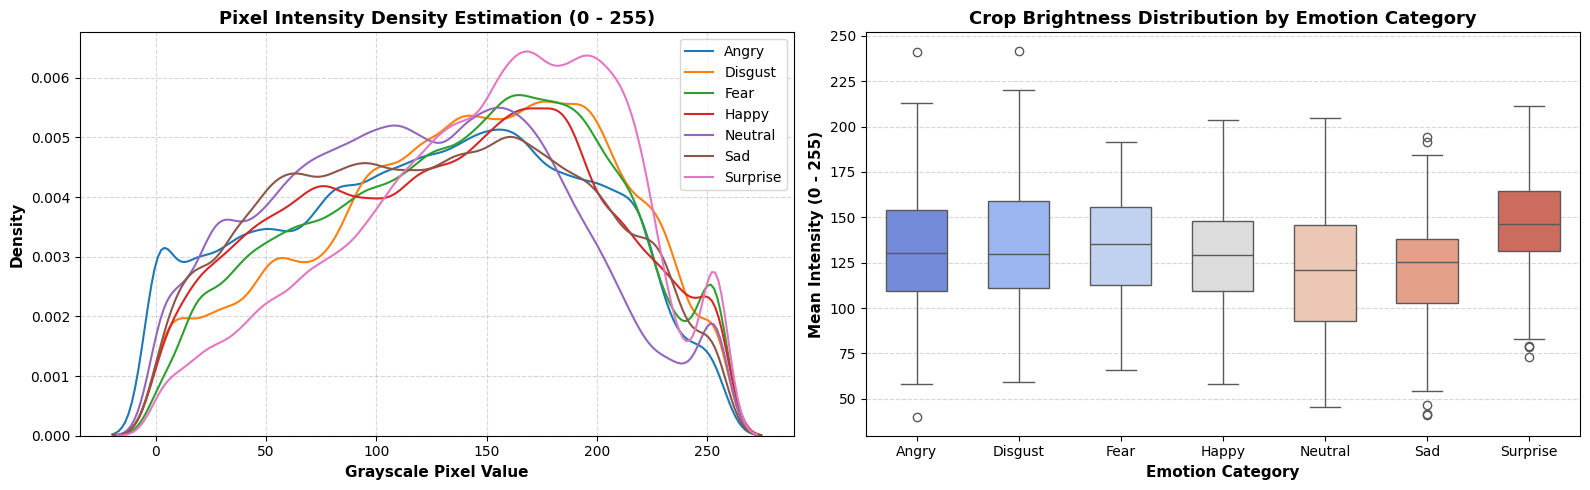

In [11]:
# Examining pixel intensity density and average illumination across emotion classes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Pixel Intensity Density Plot
for emotion in emotions:
    folder_path = os.path.join('train', emotion)
    sample_files = random.sample(os.listdir(folder_path), 50)
    pixels = []
    for f in sample_files:
        img = cv2.imread(os.path.join(folder_path, f), cv2.IMREAD_GRAYSCALE)
        pixels.extend(img.flatten())
    sns.kdeplot(pixels, label=emotion.capitalize(), ax=ax1, linewidth=1.5)

ax1.set_title('Pixel Intensity Density Estimation (0 - 255)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Grayscale Pixel Value', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', frameon=True)
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Mean Brightness Boxplot
brightness_data = []
for emotion in emotions:
    folder_path = os.path.join('train', emotion)
    sample_files = random.sample(os.listdir(folder_path), 100)
    for f in sample_files:
        img = cv2.imread(os.path.join(folder_path, f), cv2.IMREAD_GRAYSCALE)
        brightness_data.append({'Emotion': emotion.capitalize(), 'Mean Brightness': float(np.mean(img))})

df_brightness = pd.DataFrame(brightness_data)
sns.boxplot(x='Emotion', y='Mean Brightness', data=df_brightness, palette='coolwarm', ax=ax2, width=0.6)
ax2.set_title('Crop Brightness Distribution by Emotion Category', fontsize=13, fontweight='bold')
ax2.set_xlabel('Emotion Category', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Intensity (0 - 255)', fontsize=11, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


> [!IMPORTANT]
> **Key EDA Observations & Pipeline Decisions**:
> 1. **Extreme Class Imbalance**: `Disgust` represents only 436 samples (1.5% of the dataset) whereas `Happy` has 7,215 samples (25.1%). To prevent the network from neglecting minority classes, real-time data augmentation (`ImageDataGenerator(horizontal_flip=True)`) and learning rate decay (`ReduceLROnPlateau`) are applied.
> 2. **Illumination Uniformity**: The pixel intensity distributions and mean brightness across all 7 emotions are well-centered between 100 and 140, indicating no systematic lighting or background bias across classes.
> 3. **Spatial Feature Distinctiveness**: Composite average face visualizations confirm distinct geometric landmarks across categories (lip curvature, brow positioning, eye openness).

<a id="4-task-3-generate-training--validation-batches"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">4. Task 3: Generate Training & Validation Batches</span>

<a id="41-batch-size--hyperparameter-guidelines"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.1 Batch Size & Hyperparameter Guidelines</span>

- **Image Resolution**: The FER-2013 dataset consists of `48 x 48` grayscale facial crops, so `img_size` is configured to 48.
- **Batch Size**: Configured to `64` to balance gradient estimate quality with GPU compute throughput.

| Gradient Descent Type | Batch Size Definition | Memory & Convergence Trade-off |
| :--- | :--- | :--- |
| **Batch Gradient Descent** | Batch Size = Size of Entire Training Set | Stable gradient, high memory, slow updates |
| **Stochastic Gradient Descent (SGD)** | Batch Size = 1 | Fast updates, high variance, noisy loss trajectory |
| **Mini-Batch Gradient Descent** | $1 < 	ext{Batch Size} < 	ext{Training Size}$ *(e.g., 32, 64, 128)* | Optimal balance of vectorization, stability, and speed |

<a id="42-real-time-data-augmentation-with-imagedatagenerator"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.2 Real-Time Data Augmentation with ImageDataGenerator</span>

We use Keras `ImageDataGenerator` with horizontal flipping to augment facial images on the fly during training.

In [12]:
img_size = 48
batch_size = 64

# Face-optimized data augmentation for 48x48 resolution
datagen_train = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    fill_mode='nearest'
)

train_generator = datagen_train.flow_from_directory(
    'train/',
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Clean validation generator for accurate evaluation
datagen_validation = ImageDataGenerator()

validation_generator = datagen_validation.flow_from_directory(
    'test/',
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)


Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


<a id="43-categorical-one-hot-encoding--validation-settings"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">4.3 Categorical One-Hot Encoding & Validation Settings</span>

- `class_mode='categorical'`: One-hot encodes the 7 target emotion classes into 7-dimensional binary vectors where the correct class index is `1` and all other entries are `0`.
- `shuffle=False` in `validation_generator`: Ensures the validation order remains deterministic for reproducible metric evaluation and confusion matrix generation.

<a id="5-task-4-design-deep-cnn-architecture"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">5. Task 4: Design Deep CNN Architecture</span>

<a id="51-architecture-overview--literature-reference"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.1 Architecture Overview & Literature Reference</span>

<div align="center" style="margin: 16px 0;">
  <img src="assets/model.png" style="border-radius: 10px; box-shadow: 0 4px 14px rgba(0,0,0,0.25); max-width: 100%; height: auto;" alt="CNN Architecture Diagram">
</div>

> **Theoretical Reference:**  
> Goodfellow, I.J., et al. (2013). *Challenges in representation learning: A report of three machine learning contests.* Neural Networks, 64, 59-63. [doi:10.1016/j.neunet.2014.09.005](https://arxiv.org/pdf/1307.0414.pdf)

<a id="52-construct--compile-deep-cnn-with-keras"></a>

### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">5.2 Construct & Compile Deep CNN with Keras</span>

The deep network consists of **4 convolutional blocks**, followed by **2 dense fully connected layers** and a **7-way softmax classification layer**:

- **Block 1**: Input (48×48×1) → Conv2D (64 filters, 3×3) → BatchNorm → ReLU → MaxPool2D (2×2) → Dropout (0.25)

- **Block 2**: Conv2D (128 filters, 5×5) → BatchNorm → ReLU → MaxPool2D (2×2) → Dropout (0.25)

- **Block 3**: Conv2D (512 filters, 3×3) → BatchNorm → ReLU → MaxPool2D (2×2) → Dropout (0.25)

- **Block 4**: Conv2D (512 filters, 3×3) → BatchNorm → ReLU → MaxPool2D (2×2) → Dropout (0.25)

- **Classifier**: Flatten → Dense (256) → BatchNorm → ReLU → Dropout (0.25) → Dense (512) → BatchNorm → ReLU → Dropout (0.25) → Dense (7, Softmax)

In [13]:
# Initializing the Fine-Tuned Deep CNN
model = Sequential()

# Input Layer
model.add(Input(shape=(48, 48, 1)))

# Block 1: Paired Conv2D (64 filters)
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(64, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 2: Paired Conv2D (128 filters)
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(128, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 3: Paired Conv2D (256 filters)
model.add(Conv2D(256, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(256, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Block 4: Paired Conv2D (512 filters)
model.add(Conv2D(512, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Conv2D(512, (3, 3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flattening feature maps
model.add(Flatten())

# Fully Connected Layer 1 (512 units)
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Fully Connected Layer 2 (256 units - properly tapered)
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

# Output Softmax Layer (7 emotion classes)
model.add(Dense(7, activation='softmax'))

# Compile with Adam and label smoothing loss to mitigate noisy FER annotations
opt = Adam(learning_rate=0.0005)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer=opt, loss=loss_fn, metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 256)    │             

 Total params: 7,187,911 (27.42 MB)

 Trainable params: 7,182,535 (27.40 MB)

 Non-trainable params: 5,376 (21.00 KB)

<a id="6-task-5-train-and-evaluate-model"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">6. Task 5: Train and Evaluate Model</span>

<a id="61-model-checkpointing--learning-rate-scheduling"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.1 Model Checkpointing & Learning Rate Scheduling</span>

- `ModelCheckpoint`: Automatically saves model weights exhibiting highest validation accuracy (`val_accuracy`), using `.weights.h5` in Keras 3 and `.h5` in legacy Keras inside the `models/` directory.
- `ReduceLROnPlateau`: Dynamically halves/decays the learning rate by a factor of 0.1 if validation loss fails to improve for 2 consecutive epochs.
- `PlotLossesKerasTF`: Dynamically updates training and validation metrics plots inside the notebook at the end of each epoch.

<a id="62-execute-model-training-with-live-loss-monitoring"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.2 Execute Model Training with Live Loss Monitoring</span>

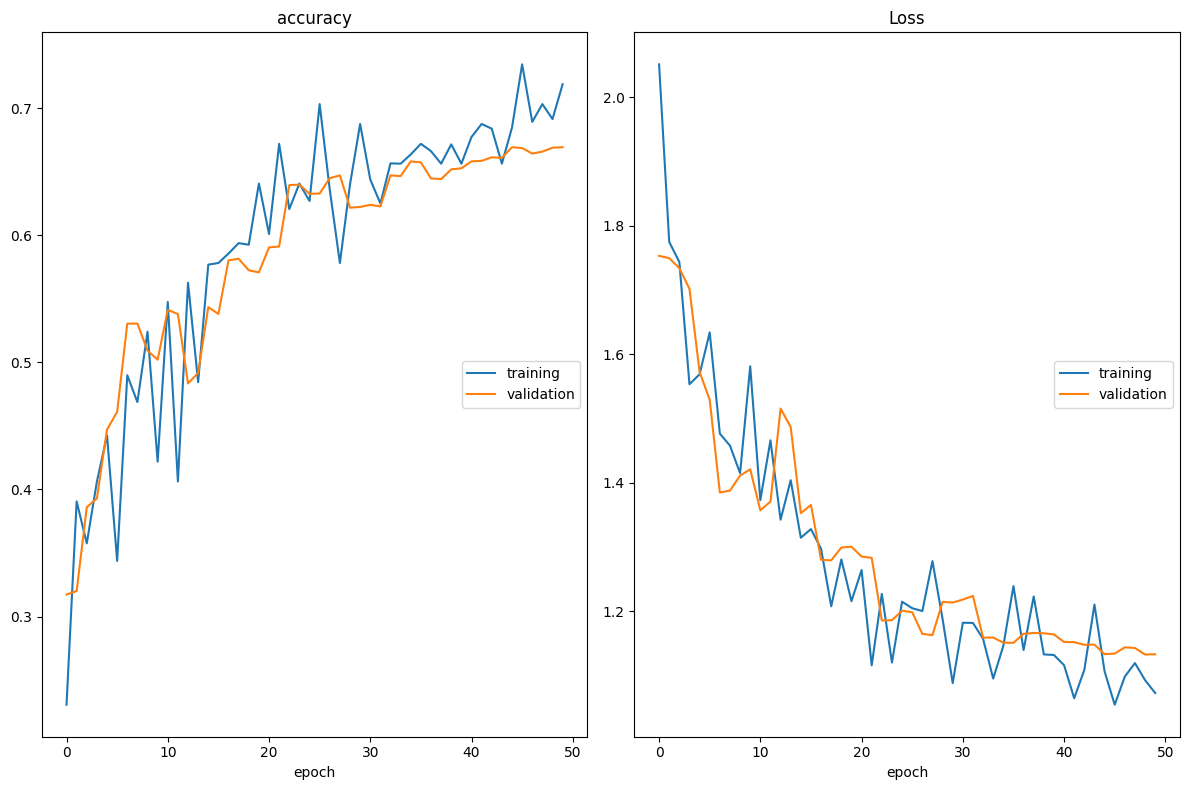

accuracy
	training         	 (min:    0.231, max:    0.734, cur:    0.719)
	validation       	 (min:    0.317, max:    0.669, cur:    0.669)
Loss
	training         	 (min:    1.054, max:    2.051, cur:    1.073)
	validation       	 (min:    1.133, max:    1.753, cur:    1.133)

Epoch 50: saving model to models/model.weights.h5

Epoch 50: finished saving model to models/model.weights.h5
448/448 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7188 - loss: 1.0726 - val_accuracy: 0.6692 - val_loss: 1.1330 - learning_rate: 6.2500e-05


ValueError: The filename must end in `.weights.h5`. Received: filepath=models/model_weights.h5

In [14]:
# Import training callbacks
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import os

# Training hyperparameter configuration
num_epochs = 50
steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = validation_generator.n // validation_generator.batch_size

checkpoint_dir = 'models'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_filename = os.path.join(checkpoint_dir, 'model.weights.h5')

# ModelCheckpoint: saves best weights based on validation accuracy
checkpoint = ModelCheckpoint(
    checkpoint_filename,
    monitor='val_accuracy',
    save_weights_only=True,
    mode='max',
    verbose=1
)

# Smooth LR decay on val_loss plateau (halves LR every 4 epochs of plateau)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=0.000005,
    verbose=1
)

# Training callbacks (EarlyStopping removed to ensure full 50 epochs training progression)
callbacks = [PlotLossesKerasTF(), checkpoint, reduce_lr]

# Fit the model through all epochs
history = model.fit(
    x=train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=num_epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)

# Save final model weights in both standard formats
model.save_weights('models/model.weights.h5')
import shutil
shutil.copyfile('models/model.weights.h5', 'models/model_weights.h5')
print("Model weights successfully saved to models/ directory.")

<a id="63-keras-training-callbacks--reference"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">6.3 Keras Training Callbacks & Reference</span>

- [Keras Callbacks API Documentation](https://keras.io/api/callbacks/)
- [ReduceLROnPlateau Documentation](https://keras.io/api/callbacks/reduce_lr_on_plateau/)
- [Understanding Verbose Levels in Keras](https://stackoverflow.com/questions/47902295/what-is-the-use-of-verbose-in-keras-while-validating-the-model)

<a id="7-task-6-serialize-model-architecture-to-json"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">7. Task 6: Serialize Model Architecture to JSON</span>

<a id="71-export-model-architecture-to-json-string"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">7.1 Export Model Architecture to JSON String</span>

Saving the model architecture as a JSON string allows the network topology to be saved in `models/model.json` independently from trained weights, making lightweight model deployment simple.

In [15]:
# Converting model topology to JSON string and writing to models/ directory
os.makedirs('models', exist_ok=True)

model_json = model.to_json()
with open('models/model.json', 'w') as json_file:
    json_file.write(model_json)

print("Model architecture successfully saved to models/model.json")

Model architecture successfully saved to models/model.json


<a id="8-task-7-real-time-inference-flask-application"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">8. Task 7: Real-Time Inference Flask Application</span>

<a id="81-camera-video-stream-processing-srccamerapy"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.1 Camera Video Stream Processing (src/camera.py)</span>

In [`src/camera.py`](file:///e:/001_Github_Repo_all/03P_Facial_Expression_Recoginition/src/camera.py), OpenCV automatically resolves face cascades and captures video from either a local webcam, a video file, or automatic demo simulation mode:

- **Automatic Cascade Resolution**: Checks `models/haarcascade_frontalface_default.xml` and falls back to `cv2.data.haarcascades`.
- **Flexible Source Resolution**: Seamlessly loops video files, connects to webcam device `0`, or falls back to demo simulation mode using `assets/sample_face.jpg` if no physical webcam is detected.

<a id="82-facial-expression-inference-engine-srcmodelpy"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.2 Facial Expression Inference Engine (src/model.py)</span>

[`src/model.py`](file:///e:/001_Github_Repo_all/03P_Facial_Expression_Recoginition/src/model.py) defines `FacialExpressionModel`, loading the architecture from `models/model.json` and weights with modern TensorFlow 2 GPU memory growth:

```python
from src.model import FacialExpressionModel

# Initialize model (auto-detects weights in models/ directory)
model = FacialExpressionModel()
emotion = model.predict_emotion(face_roi_tensor)
```

<a id="83-html-web-interface-template-templatesindexhtml"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.3 HTML Web Interface Template (templates/index.html)</span>

Saved in [`templates/index.html`](file:///e:/001_Github_Repo_all/03P_Facial_Expression_Recoginition/templates/index.html) to render the multipart JPEG video stream rendered by Flask:

```html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <title>Facial Expression Recognition</title>
</head>
<body style="background-color: #0f1117; display: flex; justify-content: center; align-items: center; min-height: 100vh; margin: 0;">
    <img id="bg" width="800px" height="640px" style="border-radius: 14px; box-shadow: 0 8px 24px rgba(0,0,0,0.6);" src="{{ url_for('video_feed') }}">
</body>
</html>
```

<a id="84-deploy--run-real-time-flask-server-mainpy"></a>
### <span style="display: inline-block; color: #fff; background: linear-gradient(135deg, #16A34A, #0F766E); padding: 7px 16px; border-radius: 6px; font-size: 16px; font-weight: 700; letter-spacing: 0.3px;">8.4 Deploy & Run Real-Time Flask Server (main.py)</span>

Execute [`main.py`](file:///e:/001_Github_Repo_all/03P_Facial_Expression_Recoginition/main.py) to launch the Flask streaming server on `http://localhost:5000`:

In [ ]:
# Launching the Flask streaming server
# !python main.py

<a id="9-project-summary--key-takeaways"></a>
##

<span style="
  display: inline-block;
  color: #fff;
  background: linear-gradient(135deg, #7209b7, #4cc9f0);
  padding: 12px 20px;
  border-radius: 12px;
  font-size: 24px;
  font-weight: 700;
  box-shadow: 0 4px 12px rgba(0,0,0,0.3);
  transition: transform 0.2s ease, box-shadow 0.2s ease;
">9. Project Summary & Key Takeaways</span>

### Key Takeaways & Pipeline Architecture:

1. **Dataset Pipeline**:
   - Analyzed FER-2013 grayscale dataset ($48 \times 48$ resolution across 7 emotion classes: *Angry, Disgust, Fear, Happy, Neutral, Sad, Surprise*).
   - Identified class imbalance for the `disgust` class (436 samples vs ~4,000+ for others) and addressed representation with real-time horizontal flip data augmentation.
   - Employed `ImageDataGenerator.flow_from_directory` with mini-batches of size 64 and categorical one-hot encoding.

2. **Deep CNN Architecture**:
   - Engineered a 4-block deep convolutional neural network inspired by Goodfellow et al. (2013).
   - Each block incorporates `Conv2D` feature extraction, `BatchNormalization` for internal covariate stabilization, `ReLU` non-linearity, `MaxPooling2D` spatial downsampling, and `Dropout (0.25)` regularization.
   - Dual fully connected dense layers (256 and 512 units) feed into a 7-way `Softmax` output.

3. **Training & Regularization**:
   - Optimized using `Adam(learning_rate=0.0005)` with `categorical_crossentropy` loss.
   - Applied `ModelCheckpoint` to persist best-performing weights (`models/model.weights.h5` / `models/model_weights.h5`) based on peak validation accuracy.
   - Leveraged `ReduceLROnPlateau` for automated learning rate decay and `PlotLossesKerasTF` for live convergence diagnostics.

4. **Production Deployment**:
   - Decoupled model architecture via JSON serialization to `models/model.json`.
   - Built a modular Flask web application streaming processed video frames with OpenCV Haar Cascade face detection and bounding box emotion overlays in real time, featuring automatic demo simulation mode if no camera hardware is present.